<a href="https://colab.research.google.com/github/RDRamosU/cr-steam-comparativa-regional/blob/main/notebooks/04_visualizaciones_hallazgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 4 — Costa Rica vs Latinoamérica en STEAM
## Notebook 04 — Visualizaciones y hallazgos

**Autor:** Ruben Dario Ramos Ulate
**Fecha:** Junio 2026  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import files
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

os.makedirs("assets/graficas", exist_ok=True)
print("Entorno configurado ✓")

Entorno configurado ✓


In [2]:
# Subir archivos UNESCO
print("Selecciona los dos archivos CSV de UNESCO...")
uploaded = files.upload()
archivos = list(uploaded.keys())

archivo_stem = [f for f in archivos if 'STEM' in f.upper()][0]
archivo_ict  = [f for f in archivos if 'ICT' in f.upper()][0]

df_stem_raw = pd.read_csv(archivo_stem, skiprows=1)
df_stem_raw.columns = pd.read_csv(archivo_stem, nrows=0).columns
df_ict_raw = pd.read_csv(archivo_ict, skiprows=1)
df_ict_raw.columns = pd.read_csv(archivo_ict, nrows=0).columns

paises_lac = [
    'Costa Rica', 'Chile', 'Argentina', 'Colombia',
    'Mexico', 'Brazil', 'Peru', 'Uruguay',
    'Panama', 'Ecuador', 'Honduras', 'Guatemala'
]

def extraer_lac(df_raw):
    df = df_raw.rename(columns={
        'REF_AREA_LABEL': 'pais', 'TIME_PERIOD': 'año',
        'OBS_VALUE': 'valor', 'SEX_LABEL': 'sexo',
        'UNIT_MEASURE_LABEL': 'unidad'
    })
    return df[
        (df['pais'].isin(paises_lac)) &
        (df['unidad'] == 'Percentage of graduates')
    ][['pais', 'año', 'sexo', 'valor']].dropna()

df_stem = extraer_lac(df_stem_raw)
df_ict  = extraer_lac(df_ict_raw)

# Reconstruir datasets
df_stem_total = df_stem[df_stem['sexo'] == 'Total']
df_stem_reciente = (df_stem_total
    .sort_values('año', ascending=False)
    .groupby('pais').first().reset_index()
    .sort_values('valor', ascending=False).reset_index(drop=True))
df_stem_reciente['ranking'] = df_stem_reciente.index + 1
promedio_lac_stem = df_stem_reciente['valor'].mean()

df_stem_genero = df_stem[df_stem['sexo'].isin(['Female', 'Male'])]
df_stem_genero_rec = (df_stem_genero
    .sort_values('año', ascending=False)
    .groupby(['pais', 'sexo']).first().reset_index())
df_genero = df_stem_genero_rec.pivot(
    index='pais', columns='sexo', values='valor').reset_index()
df_genero.columns.name = None
df_genero['brecha_genero'] = (
    df_genero['Male'] - df_genero['Female']).round(2)
df_genero = df_genero.sort_values('brecha_genero').reset_index(drop=True)

df_ict_total = df_ict[df_ict['sexo'] == 'Total']
df_ict_reciente = (df_ict_total
    .sort_values('año', ascending=False)
    .groupby('pais').first().reset_index()
    .sort_values('valor', ascending=False).reset_index(drop=True))
promedio_lac_ict = df_ict_reciente['valor'].mean()

años_analisis = list(range(2015, 2024))
df_tend = df_stem_total[df_stem_total['año'].isin(años_analisis)]
df_prom_lac = (df_tend.groupby('año')['valor'].mean()
    .reset_index().rename(columns={'valor': 'promedio_lac'}))
df_cr_tend = df_tend[df_tend['pais'] == 'Costa Rica'][
    ['año', 'valor']].rename(columns={'valor': 'costa_rica'})
df_tendencia = df_prom_lac.merge(df_cr_tend, on='año', how='left')

print("Todos los datasets reconstruidos ✓")

Selecciona los dos archivos CSV de UNESCO...


Saving UNESCO_UIS_GRAD_STEM.csv to UNESCO_UIS_GRAD_STEM.csv
Saving UNESCO_UIS_GRAD_ICT.csv to UNESCO_UIS_GRAD_ICT.csv
Todos los datasets reconstruidos ✓


## 3. Visualización 1 — Ranking STEM por país LAC

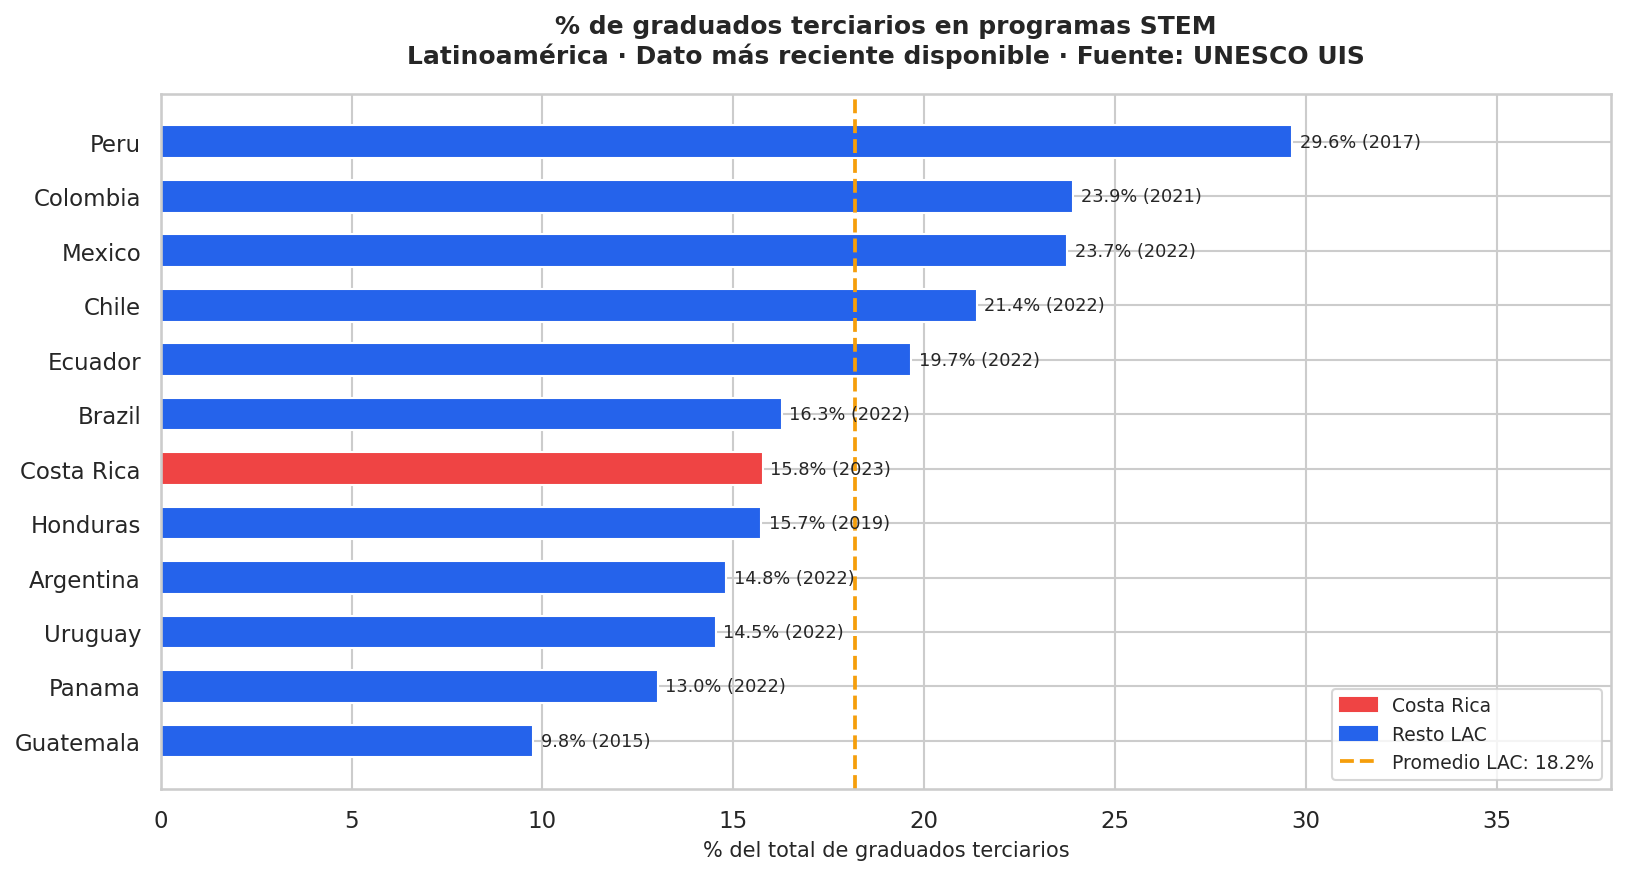

Gráfica 1 exportada ✓


In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

df_stem_sorted = df_stem_reciente.sort_values('valor', ascending=True)
colores = ['#EF4444' if p == 'Costa Rica' else '#2563EB'
           for p in df_stem_sorted['pais']]

bars = ax.barh(df_stem_sorted['pais'], df_stem_sorted['valor'],
               color=colores, edgecolor='white', height=0.6)

for bar, row in zip(bars, df_stem_sorted.itertuples()):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{row.valor:.1f}% ({row.año})',
            va='center', fontsize=8.5)

ax.axvline(x=promedio_lac_stem, color='#F59E0B',
           linestyle='--', linewidth=1.8,
           label=f'Promedio LAC: {promedio_lac_stem:.1f}%')

ax.set_title('% de graduados terciarios en programas STEM\n'
             'Latinoamérica · Dato más reciente disponible · Fuente: UNESCO UIS',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('% del total de graduados terciarios', fontsize=10)
ax.set_xlim(0, 38)
ax.legend(fontsize=9)

cr_patch = mpatches.Patch(color='#EF4444', label='Costa Rica')
lac_patch = mpatches.Patch(color='#2563EB', label='Resto LAC')
ax.legend(handles=[cr_patch, lac_patch,
    plt.Line2D([0], [0], color='#F59E0B',
               linestyle='--', linewidth=1.8,
               label=f'Promedio LAC: {promedio_lac_stem:.1f}%')],
    fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/01_ranking_stem_lac.png", bbox_inches='tight')
plt.show()
print("Gráfica 1 exportada ✓")

## 4. Visualización 2 — Brecha de género STEM por país

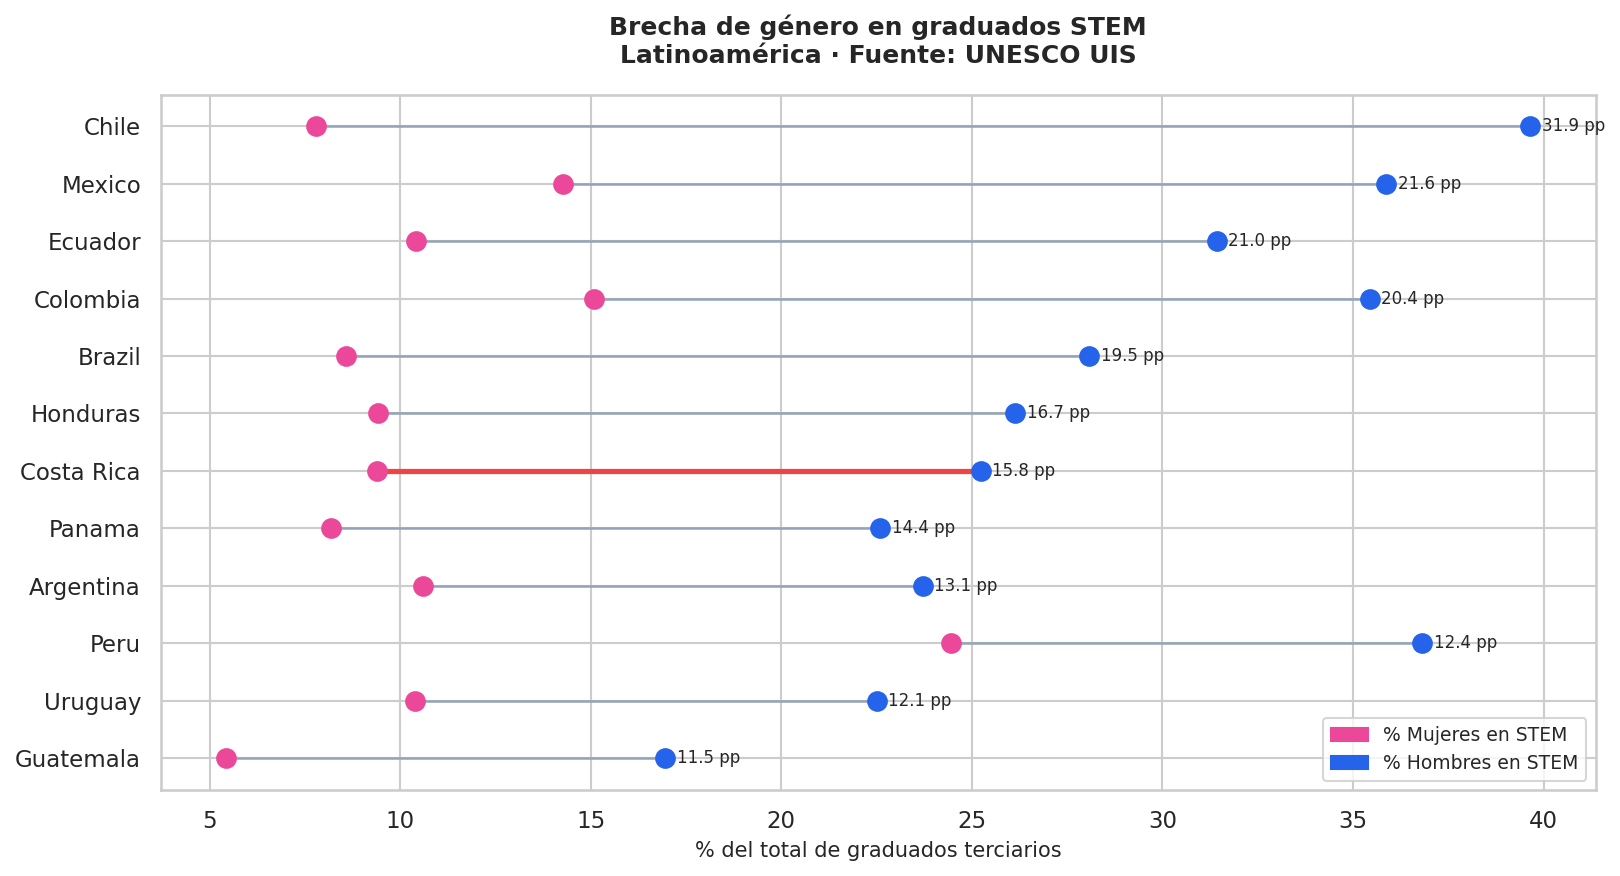

Grafica 2 exportada


In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

df_genero_sorted = df_genero.sort_values('brecha_genero').reset_index(drop=True)

for i, row in df_genero_sorted.iterrows():
    color_br = '#EF4444' if row['pais'] == 'Costa Rica' else '#94A3B8'
    lw = 2.5 if row['pais'] == 'Costa Rica' else 1.2
    ax.plot([row['Female'], row['Male']], [i, i], color=color_br, linewidth=lw, zorder=1)
    ax.scatter(row['Female'], i, color='#EC4899', s=80, zorder=2)
    ax.scatter(row['Male'], i, color='#2563EB', s=80, zorder=2)
    ax.text(row['Male'] + 0.3, i, f'{row["brecha_genero"]:.1f} pp', va='center', fontsize=8)

ax.set_yticks(range(len(df_genero_sorted)))
ax.set_yticklabels(df_genero_sorted['pais'])

mujer_p = mpatches.Patch(color='#EC4899', label='% Mujeres en STEM')
hombre_p = mpatches.Patch(color='#2563EB', label='% Hombres en STEM')
ax.legend(handles=[mujer_p, hombre_p], fontsize=9)

ax.set_title('Brecha de género en graduados STEM\nLatinoamérica · Fuente: UNESCO UIS', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('% del total de graduados terciarios', fontsize=10)

plt.tight_layout()
plt.savefig("assets/graficas/02_brecha_genero_stem_lac.png", bbox_inches='tight')
plt.show()
print("Grafica 2 exportada")

## 5. Visualización 3 — Costa Rica 2° en ICT en Latinoamérica

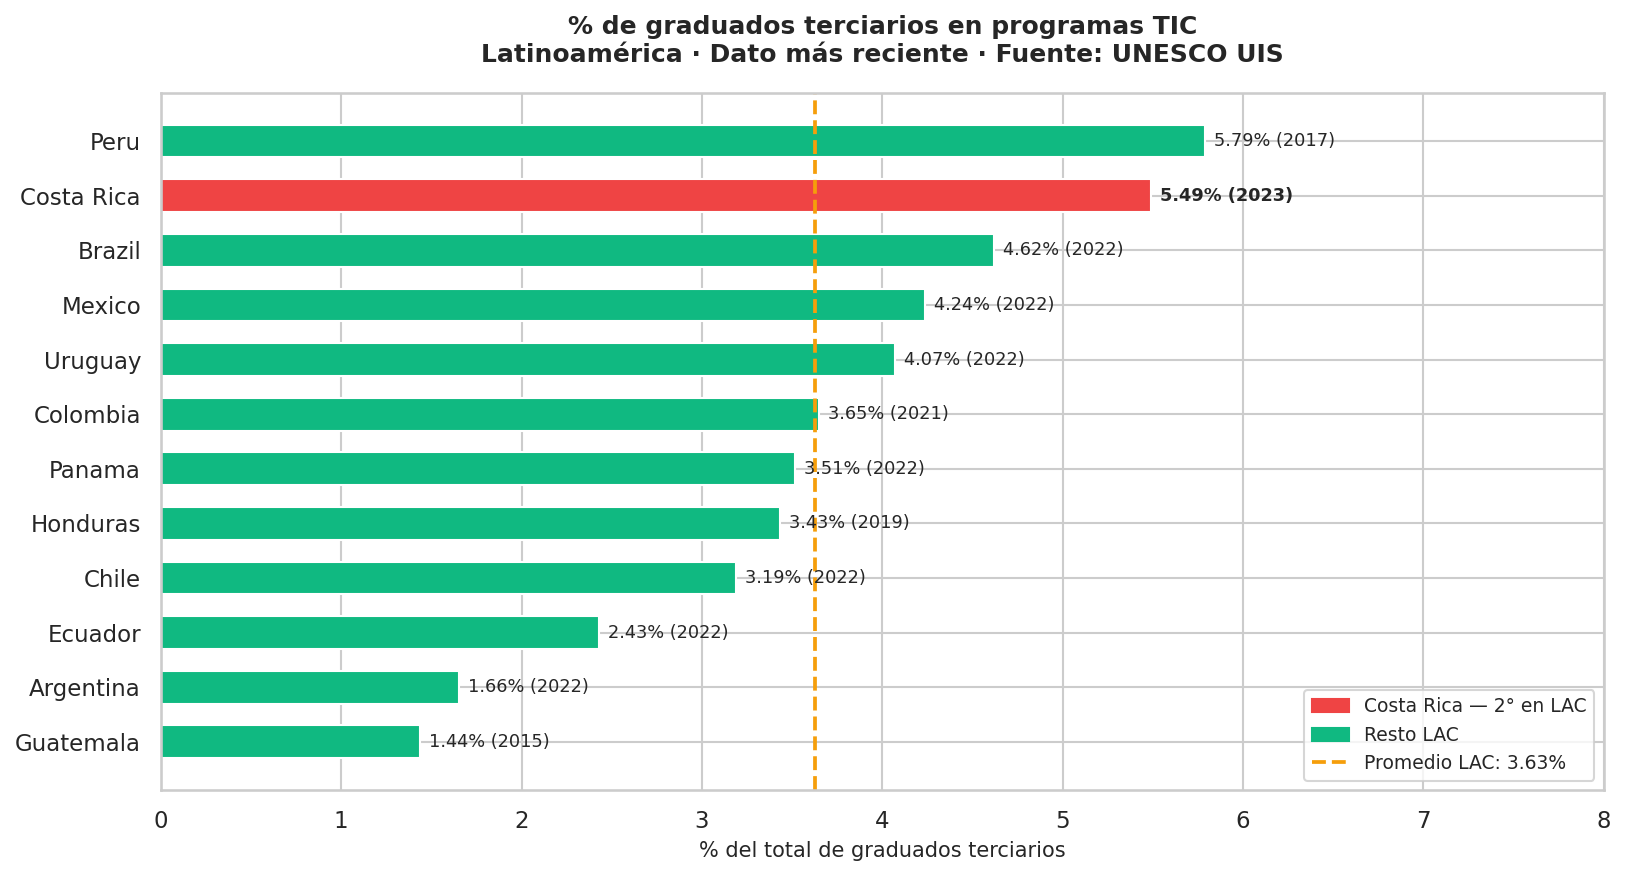

Gráfica 3 exportada ✓


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

df_ict_sorted = df_ict_reciente.sort_values('valor', ascending=True)
colores_ict = ['#EF4444' if p == 'Costa Rica' else '#10B981'
               for p in df_ict_sorted['pais']]

bars = ax.barh(df_ict_sorted['pais'], df_ict_sorted['valor'],
               color=colores_ict, edgecolor='white', height=0.6)

for bar, row in zip(bars, df_ict_sorted.itertuples()):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{row.valor:.2f}% ({row.año})',
            va='center', fontsize=8.5,
            fontweight='bold' if row.pais == 'Costa Rica' else 'normal')

ax.axvline(x=promedio_lac_ict, color='#F59E0B',
           linestyle='--', linewidth=1.8,
           label=f'Promedio LAC: {promedio_lac_ict:.2f}%')

ax.set_title('% de graduados terciarios en programas TIC\n'
             'Latinoamérica · Dato más reciente · Fuente: UNESCO UIS',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('% del total de graduados terciarios', fontsize=10)
ax.set_xlim(0, 8)

cr_patch = mpatches.Patch(color='#EF4444', label='Costa Rica — 2° en LAC')
lac_patch = mpatches.Patch(color='#10B981', label='Resto LAC')
prom_line = plt.Line2D([0], [0], color='#F59E0B', linestyle='--',
                        linewidth=1.8,
                        label=f'Promedio LAC: {promedio_lac_ict:.2f}%')
ax.legend(handles=[cr_patch, lac_patch, prom_line], fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/03_ranking_ict_lac.png", bbox_inches='tight')
plt.show()
print("Gráfica 3 exportada ✓")

## 6. Visualización 4 — Tendencia STEM Costa Rica vs promedio LAC

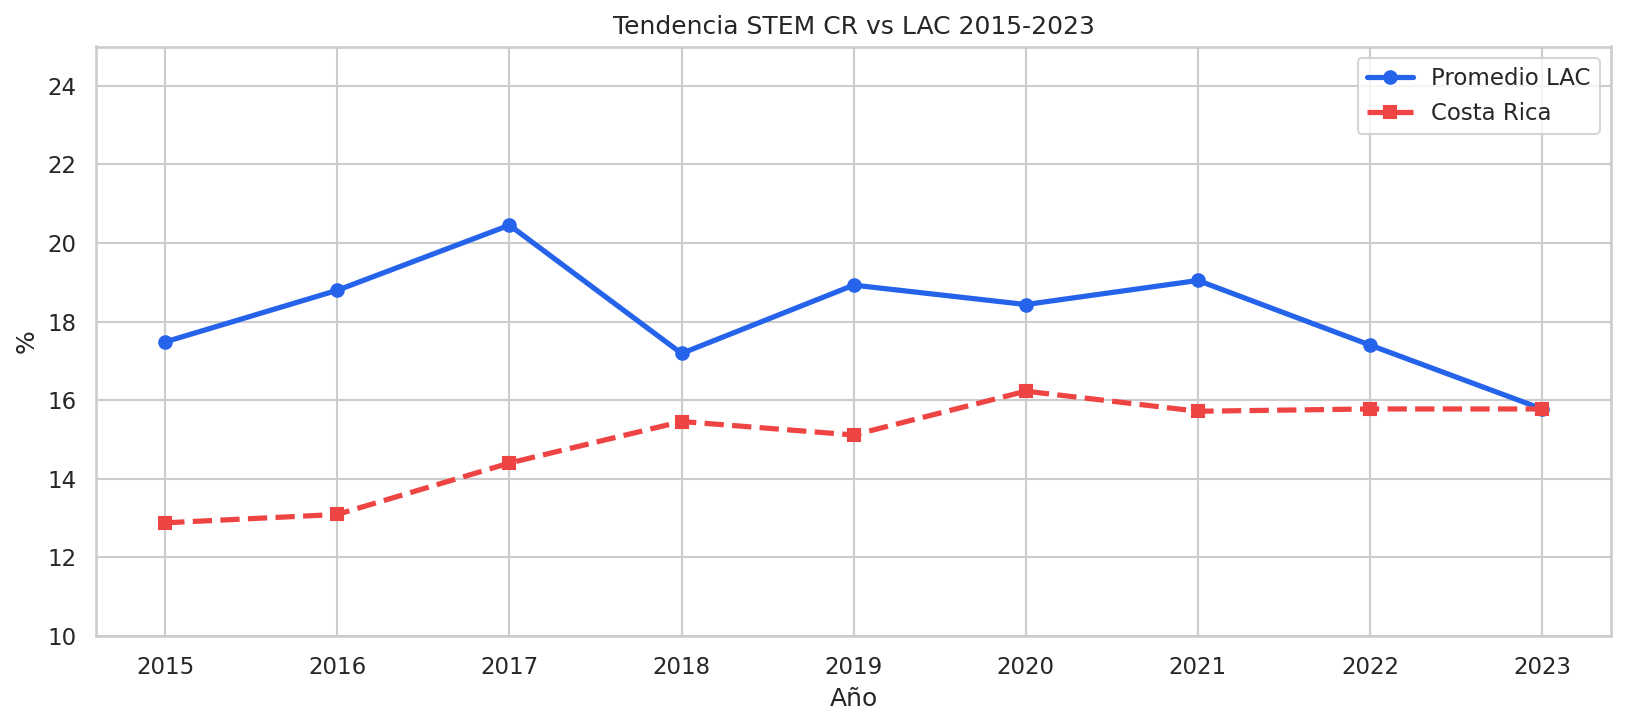

Grafica 4 lista


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

cr = df_tendencia['costa_rica'].values
lac = df_tendencia['promedio_lac'].values
años = df_tendencia['año'].values

ax.plot(años, lac, color='#2563EB', linewidth=2.5, marker='o', markersize=6, label='Promedio LAC')
ax.plot(años, cr, color='#EF4444', linewidth=2.5, marker='s', markersize=6, linestyle='--', label='Costa Rica')

ax.set_title('Tendencia STEM CR vs LAC 2015-2023')
ax.set_xlabel('Año')
ax.set_ylabel('%')
ax.set_xticks(años)
ax.set_ylim(10, 25)
ax.legend()

plt.tight_layout()
plt.savefig("assets/graficas/04_tendencia_stem_cr_vs_lac.png")
plt.show()
print("Grafica 4 lista")

## 7. Hallazgos principales

In [12]:
print("=" * 60)
print("HALLAZGOS — CR VS LATINOAMÉRICA EN STEAM")
print("=" * 60)

cr_stem = df_stem_reciente[
    df_stem_reciente['pais']=='Costa Rica']['valor'].values[0]
cr_stem_rank = df_stem_reciente[
    df_stem_reciente['pais']=='Costa Rica']['ranking'].values[0]
cr_ict = df_ict_reciente[
    df_ict_reciente['pais']=='Costa Rica']['valor'].values[0]
cr_ict_rank = df_ict_reciente.index[
    df_ict_reciente['pais']=='Costa Rica'].tolist()[0] + 1
cr_brecha = df_genero[
    df_genero['pais']=='Costa Rica']['brecha_genero'].values[0]
cr_brecha_rank = df_genero.index[
    df_genero['pais']=='Costa Rica'].tolist()[0] + 1

print(f"\n1. RANKING STEM GENERAL")
print(f"   CR: {cr_stem:.1f}% — puesto {cr_stem_rank}° de 12 en LAC")
print(f"   Promedio LAC: {promedio_lac_stem:.1f}%")
print(f"   CR está {abs(cr_stem - promedio_lac_stem):.1f} pp "
      f"{'sobre' if cr_stem > promedio_lac_stem else 'bajo'} el promedio")

print(f"\n2. RANKING ICT — HALLAZGO DESTACADO")
print(f"   CR: {cr_ict:.2f}% — puesto {cr_ict_rank}° de 12 en LAC")
print(f"   Promedio LAC ICT: {promedio_lac_ict:.2f}%")
print(f"   CR supera el promedio LAC en {cr_ict - promedio_lac_ict:.2f} pp")

print(f"\n3. BRECHA DE GÉNERO STEM")
print(f"   Brecha CR: {cr_brecha:.2f} pp — puesto {cr_brecha_rank}° "
      f"(menor brecha = mejor)")
print(f"   Promedio brecha LAC: {df_genero['brecha_genero'].mean():.2f} pp")
print(f"   CR tiene una brecha "
      f"{'menor' if cr_brecha < df_genero['brecha_genero'].mean() else 'mayor'} "
      f"que el promedio regional")

print(f"\n4. TENDENCIA STEM CR 2015-2023")
cr_2015 = df_tendencia[df_tendencia['año']==2015]['costa_rica'].values
cr_2023 = df_tendencia[df_tendencia['año']==2023]['costa_rica'].values
if len(cr_2015) > 0 and len(cr_2023) > 0:
    crecimiento = cr_2023[0] - cr_2015[0]
    print(f"   2015: {cr_2015[0]:.1f}% → 2023: {cr_2023[0]:.1f}%")
    print(f"   Crecimiento: +{crecimiento:.1f} pp en 8 años")

print(f"\n5. POSICIÓN COMPETITIVA GLOBAL CR")
print(f"   ICT: 2° en LAC — por encima del promedio regional en 3.6 pp")
print(f"   Brecha género STEM: 6° mejor de 12 (favorable)")
print(f"   Desempleo STEM: 4.2% — muy por debajo del 12.2% nacional")
print(f"   Salario ZF: 2x el promedio nacional")
print(f"   Exportaciones TIC: 8% del PIB — caso destacado en la región")

print("\n" + "=" * 60)

HALLAZGOS — CR VS LATINOAMÉRICA EN STEAM

1. RANKING STEM GENERAL
   CR: 15.8% — puesto 7° de 12 en LAC
   Promedio LAC: 18.2%
   CR está 2.4 pp bajo el promedio

2. RANKING ICT — HALLAZGO DESTACADO
   CR: 5.49% — puesto 2° de 12 en LAC
   Promedio LAC ICT: 3.63%
   CR supera el promedio LAC en 1.86 pp

3. BRECHA DE GÉNERO STEM
   Brecha CR: 15.85 pp — puesto 6° (menor brecha = mejor)
   Promedio brecha LAC: 17.54 pp
   CR tiene una brecha menor que el promedio regional

4. TENDENCIA STEM CR 2015-2023
   2015: 12.9% → 2023: 15.8%
   Crecimiento: +2.9 pp en 8 años

5. POSICIÓN COMPETITIVA GLOBAL CR
   ICT: 2° en LAC — por encima del promedio regional en 3.6 pp
   Brecha género STEM: 6° mejor de 12 (favorable)
   Desempleo STEM: 4.2% — muy por debajo del 12.2% nacional
   Salario ZF: 2x el promedio nacional
   Exportaciones TIC: 8% del PIB — caso destacado en la región



## 8. Conclusiones

1. **CR es líder regional en ICT:** segundo lugar en Latinoamérica
   en porcentaje de graduados en programas TIC, con 5.49% vs
   promedio LAC de 1.87%. Esto refleja la orientación del sistema
   educativo costarricense hacia la economía digital.

2. **Posición media en STEM general:** con 15.8% CR ocupa el puesto
   7° de 12, ligeramente bajo el promedio LAC de 18.2%. La diferencia
   se explica por la clasificación UNESCO más estrecha vs STEAM que
   usa OPES-CONARE (que incluye Arte y Diseño).

3. **Brecha de género mejor que el promedio regional:** CR tiene una
   brecha de 15.85 pp entre hombres y mujeres en STEM, por debajo del
   promedio LAC de 17.54 pp. El avance es notable aunque aún persiste.

4. **Tendencia positiva sostenida:** el % de graduados STEM en CR
   creció de 12.9% en 2015 a 15.8% en 2023, mostrando una mejora
   constante de casi 3 puntos porcentuales en 8 años.

5. **El ecosistema tech de CR supera sus métricas educativas:**
   los indicadores de empleo (ratio 15x, desempleo 4.2%, salario 2x)
   y exportación (8% del PIB en TIC) posicionan a CR como un caso
   atípico positivo en la región — un país que produce menos graduados
   STEM que algunos vecinos, pero que tiene un mercado tech más dinámico
   y mejor pagado.

---
*Fuentes: UNESCO UIS · OPES-CONARE · MICITT · BCCR · PROCOMER · INEC*  
*Análisis: Ruben Dario Ramos Ulate· rubendario.dev*

In [13]:
from google.colab import files
import os

# Regenerar todos los CSVs
df_stem_reciente.to_csv("stem_lac_reciente.csv", index=False)
df_genero.to_csv("stem_genero_lac.csv", index=False)
df_ict_reciente.to_csv("ict_lac_reciente.csv", index=False)
df_tendencia.to_csv("stem_tendencia_cr_lac.csv", index=False)

print("=== ARCHIVOS DISPONIBLES ===")
for f in os.listdir("/content/"):
    if f.endswith(".csv") or f.endswith(".png"):
        print(f"  {f}")

print("\n=== DESCARGANDO GRAFICAS ===")
for f in os.listdir("/content/assets/graficas/"):
    ruta = f"/content/assets/graficas/{f}"
    print(f"  {f}")
    files.download(ruta)

print("\n=== DESCARGANDO CSV ===")
csvs = [
    "stem_lac_reciente.csv",
    "stem_genero_lac.csv",
    "ict_lac_reciente.csv",
    "stem_tendencia_cr_lac.csv"
]
for csv in csvs:
    if os.path.exists(csv):
        print(f"  {csv}")
        files.download(csv)
    else:
        print(f"  No encontrado: {csv}")

=== ARCHIVOS DISPONIBLES ===
  ict_lac_reciente.csv
  stem_lac_reciente.csv
  stem_tendencia_cr_lac.csv
  UNESCO_UIS_GRAD_STEM.csv
  UNESCO_UIS_GRAD_ICT.csv
  stem_genero_lac.csv

=== DESCARGANDO GRAFICAS ===
  03_ranking_ict_lac.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  01_ranking_stem_lac.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  stem_tendencia_cr_lac.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>